<a href="https://colab.research.google.com/github/crreyes-unal/Reporte-problemas-MpAM/blob/main/Ejercicio11__RectasSeparar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***¿Cuál es el número efectivo de líneas (rectas) para separar 5 puntos (en 2 etiquetas) $\mathbb{R}^2$? (Ver todas las rectas posibles que separan 2 clases compuestas por 5 puntos, discriminar los casos en los que una recta no puede separar y así encontrar el número de rectas efectivas.)***

El problema se puede reinterpretar como sigue. Dado un conjunto de $N = 5$ puntos en $\mathbb{R}^2$ en posición general, es decir, ninguna terna de puntos es colineal, se quiere saber cuántas asignaciones de etiquetas binarias $y_i \in \{-1, +1\}$ pueden ser separadas mediante una recta en el plano. Esto es un problema combinatorio, así, para hacer los cálculos se halla cada parte.

* Espacio total de combinaciones: Para $N = 5$ puntos, existen $2^5 = 32$ posibles formas de etiquetar los puntos con 2 clases.

Se quiere saber ¿cuántas de estas 32 combinaciones son linealmente separables? Esto es, hallar el número efectivo de rectas o dicotomías.

El teorema de Cover establece que el número máximo de dicotomías linealmente separables que un hiperplano en $\mathbb{R}^d$ puede inducir sobre $N$ puntos en posición general viene dado por $m_{\mathcal{H}}(N)$ donde

$$m_{\mathcal{H}}(N) = 2 \sum_{k=0}^{d} \binom{N-1}{k}$$

Para este caso particular en el plano $\mathbb{R}^2$ ($d = 2$) y con $N = 5$ puntos se tiene entonces

$$m_{\mathcal{H}}(5) = 2 \left[ \binom{5-1}{0} + \binom{5-1}{1} + \binom{5-1}{2} \right]$$

Calculando cada combinación
* $\binom{4}{0} = 1$
* $\binom{4}{1} = 4$
* $\binom{4}{2} = \frac{4 \times 3}{2} = 6$

Sustituyendo en la expresión:

$$m_{\mathcal{H}}(5) = 2 \times (1 + 4 + 6) = 2 \times 11 = 22$$

De las $2^5 = 32$ etiquetados posibles, 22 son linealmente separables y 10 no son separables.

Si se consideran 5 puntos organizados en posición convexa, es decir, los vértices de un pentágono convexo podemos examinar cada caso pedido en la siguiente tabla

| Clases | Combinaciones Totales | Separables linealmente | No separables |
|---|---|---|---|
| 5 de una clase y 0 de otra | $\binom{5}{0} + \binom{5}{5} = 2$ | 2 | 0 |
| 4 de una clase y 1 de otra | $\binom{5}{1} + \binom{5}{4} = 10$ | 10| 0 |
| 3 de una clase y 2 de otra | $\binom{5}{2} + \binom{5}{3} = 20$ | 10 (solo vértices adyacentes) | 10  |
| TOTAL | 32 | 22 | 10 |

Los 10 casos no separables ocurren cuando dos puntos de la misma clase están separados de forma intercalada por puntos de la otra clase, esto es análogo al problema de XOR tratado en ejercicios de este repositorio, impidiendo que una única recta trace la frontera sin cortar la pertenencia.

Podemos representar lo anterior con la siguiente gráfica

Total combinaciones posibles (2^5) : 32
Casos SEPARABLES por recta        : 22
Casos NO SEPARABLES              : 10


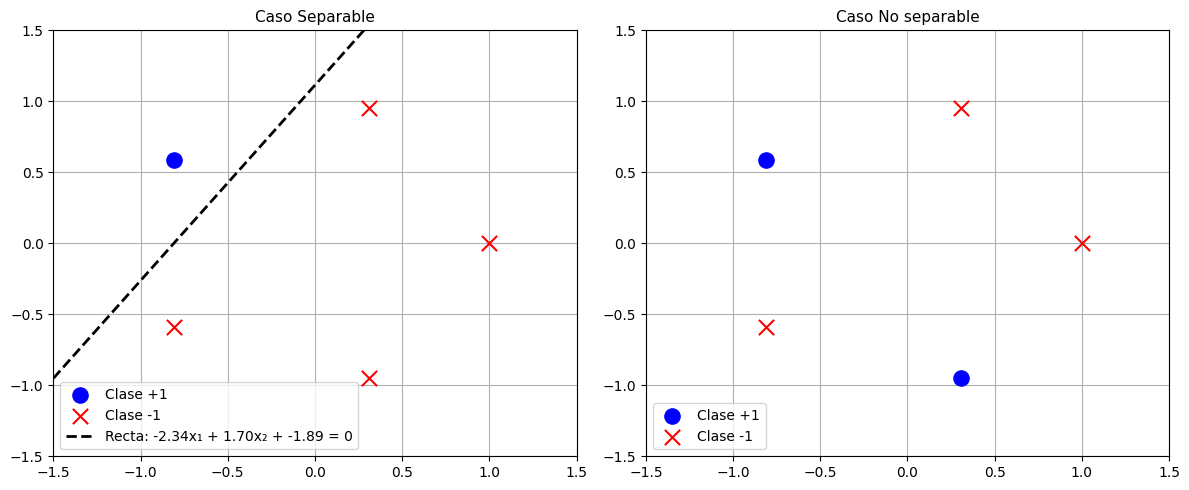

In [3]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

def evaluar_separabilidad_lineal(X: np.ndarray, y: np.ndarray):
    """
    Evalúa si un conjunto de puntos x con etiquetas y es separable por una recta
    utilizando programación lineal.
    Retorna: (es_separable, w1, w2, b)
    """
    N, d = X.shape

    # Formular restricción:
    A_ub = -y[:, None] * np.hstack([X, np.ones((N, 1))])
    b_ub = -np.ones(N)

    # Función objetivo cero
    c = np.zeros(d + 1)

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(None, None), method='highs')

    if res.success:
        w1, w2, b = res.x
        return True, w1, w2, b

    return False, None, None, None


#Experimento

# 1. Crear 5 puntos en un poligono regular
angulos = np.linspace(0, 2 * np.pi, 5, endpoint=False)
X_puntos = np.column_stack([np.cos(angulos), np.sin(angulos)])

# 2. Generar todas las 2^5 = 32 combinaciones de etiquetas
todas_las_etiquetas = list(itertools.product([-1, 1], repeat=5))

casos_separables = []
casos_no_separables = []

#Etiquetas
for tuple_y in todas_las_etiquetas:
    y_vector = np.array(tuple_y)
    es_sep, w1, w2, b = evaluar_separabilidad_lineal(X_puntos, y_vector)

    if es_sep:
        casos_separables.append((y_vector, w1, w2, b))
    else:
        casos_no_separables.append(y_vector)

print(f"Total combinaciones posibles (2^5) : {len(todas_las_etiquetas)}")
print(f"Casos SEPARABLES por recta        : {len(casos_separables)}")
print(f"Casos NO SEPARABLES              : {len(casos_no_separables)}")


# Gráfica

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Separable
y_sep, w1, w2, b = casos_separables[4]

axes[0].scatter(X_puntos[y_sep == 1, 0], X_puntos[y_sep == 1, 1], color='blue', s=120, label='Clase +1', zorder=3)
axes[0].scatter(X_puntos[y_sep == -1, 0], X_puntos[y_sep == -1, 1], color='red', marker='x', s=120, label='Clase -1', zorder=3)

# Recta
x1_rango = np.linspace(-1.5, 1.5, 100)
x2_rango = -(w1 * x1_rango + b) / w2

axes[0].plot(x1_rango, x2_rango, 'k--', linewidth=2, label=f'Recta: {w1:.2f}x₁ + {w2:.2f}x₂ + {b:.2f} = 0')
axes[0].set_xlim([-1.5, 1.5])
axes[0].set_ylim([-1.5, 1.5])
axes[0].set_title("Caso Separable", fontsize=11)
axes[0].legend(loc='lower left')
axes[0].grid(True)

# 2: No separabale
y_no_sep = casos_no_separables[0]

axes[1].scatter(X_puntos[y_no_sep == 1, 0], X_puntos[y_no_sep == 1, 1], color='blue', s=120, label='Clase +1', zorder=3)
axes[1].scatter(X_puntos[y_no_sep == -1, 0], X_puntos[y_no_sep == -1, 1], color='red', marker='x', s=120, label='Clase -1', zorder=3)

axes[1].set_xlim([-1.5, 1.5])
axes[1].set_ylim([-1.5, 1.5])
axes[1].set_title("Caso No separable", fontsize=11)
axes[1].legend(loc='lower left')
axes[1].grid(True)

plt.tight_layout()
plt.show()